In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zusmani/pakistan-toshakhana-files/Refined_TK_data ver 2.csv
/kaggle/input/datasets/zusmani/pakistan-toshakhana-files/Toshakhana Files 2.xlsx


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/zusmani/pakistan-toshakhana-files/Refined_TK_data ver 2.csv")

# Display first 5 rows
df.head()

,Detail of Gifts,Item Category,Name of Recipient,Affiliation,Date,Assessed Value,Retention Cost,Retained,Remarks
0,Two small silver\nBowls,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharrafarraf,1/8/2002,5000.0,0.0,Yes,Yes
1,One Pilot Pen with\nink,Pen,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharraf,1/8/2002,3500.0,0.0,Yes,Yes
2,One silver vase,Decoration Pieces,"Mr. Shaukat Aziz, Minister for Finance",Gen. Musharraf,1/9/2002,7500.0,0.0,Yes,Yes
3,One (decoration)\nfolding Screen,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nAf...",Gen. Musharraf,1/15/2002,2200.0,0.0,Yes,Yes
4,One Decoration\nPiece,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharraf,1/22/2002,2000.0,0.0,Yes,Yes


## 3. Dataset Dimensions

The shape of the dataset is checked to determine the total number of rows and columns.

In [52]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4214
Number of Columns: 9


## 4. Dataset Columns

The column names are displayed to understand the variables available in the dataset.

In [53]:
df.columns

Index(['Detail of Gifts', 'Item Category', 'Name of Recipient', 'Affiliation',
       'Date', 'Assessed Value', 'Retention Cost', 'Retained', 'Remarks'],
      dtype='object')

## 5. Dataset Information

The `info()` function is used to examine the data types, number of non-null values, and memory usage of the dataset.

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4214 entries, 0 to 4213
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Detail of Gifts    4208 non-null   object 
 1   Item Category      2338 non-null   object 
 2   Name of Recipient  4214 non-null   object 
 3   Affiliation        3207 non-null   object 
 4   Date               4211 non-null   object 
 5   Assessed Value     4213 non-null   float64
 6   Retention Cost     4205 non-null   float64
 7   Retained           4203 non-null   object 
 8   Remarks            4203 non-null   object 
dtypes: float64(2), object(7)
memory usage: 296.4+ KB


## 6. Statistical Summary

Descriptive statistics are generated to understand the distribution of numerical and categorical variables.

In [55]:
df.describe(include="all")

,Detail of Gifts,Item Category,Name of Recipient,Affiliation,Date,Assessed Value,Retention Cost,Retained,Remarks
count,4208,2338,4214,3207,4211,4.213000e+03,4.205000e+03,4203,4203
unique,3248,22,2047,12,1450,NaN,NaN,72,229
top,One Carpet,Watch,"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",Military,7/22/2010,NaN,NaN,Yes,Yes
freq,53,1102,698,734,47,NaN,NaN,3730,3730
mean,NaN,NaN,NaN,NaN,NaN,3.210531e+05,4.851276e+04,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,3.894070e+06,6.184538e+05,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.700000e+03,0.000000e+00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,8.000000e+03,0.000000e+00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,4.000000e+04,2.250000e+03,NaN,NaN


## 7. Missing Values Analysis

Missing values are identified in each column to assess the quality and completeness of the dataset.

In [56]:
df.isnull().sum()

Detail of Gifts         6
Item Category        1876
Name of Recipient       0
Affiliation          1007
Date                    3
Assessed Value          1
Retention Cost          9
Retained               11
Remarks                11
dtype: int64

## 8. Duplicate Records

Duplicate records are identified to determine whether repeated entries exist in the dataset.

In [57]:
df.duplicated().sum()

np.int64(16)

## 9. Data Cleaning

Data cleaning is performed to improve the quality and consistency of the dataset before conducting exploratory analysis. This includes checking duplicates, missing values, data types, and inconsistent values.

### 9.1 Checking Data Types

The data types of all columns are examined to identify columns that may require conversion or further preprocessing.

In [58]:
df.dtypes

Detail of Gifts       object
Item Category         object
Name of Recipient     object
Affiliation           object
Date                  object
Assessed Value       float64
Retention Cost       float64
Retained              object
Remarks               object
dtype: object

### 9.2 Checking Duplicate Records

Duplicate records can affect the accuracy of analysis. Therefore, duplicate rows are identified before further processing.

In [59]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 16


In [60]:
df[df.duplicated()]

,Detail of Gifts,Item Category,Name of Recipient,Affiliation,Date,Assessed Value,Retention Cost,Retained,Remarks
115,One carpet,Carpet,Minister for Petroleum & Natural\nResources,Gen. Musharraf,6/4/2002,7000.0,0.0,Yes,Yes
170,One saree,Clothes,"Begum General Parvez Musharraf,\nPresident/...",Military,8/10/2002,1500.0,0.0,Yes,Yes
467,One piece Ghilaf e\nKaaba,NaN,"Mir Zafarullah Khan\nJamali, Prime\nMiniste...",Gen. Musharraf,9/2/2003,0.0,0.0,Yes,Yes
540,NaN,NaN,"Mir Zafarullah Khan\nJamali, Prime\nMiniste...",Gen. Musharraf,12/19/2003,0.0,0.0,NaN,NaN
541,NaN,NaN,"Mir Zafarullah Khan\nJamali, Prime\nMiniste...",Gen. Musharraf,12/19/2003,0.0,0.0,NaN,NaN
1538,One shield,NaN,"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",Gen Mus,5/25/2006,0.0,0.0,Yes,Yes
1650,One shield,NaN,"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",Gen Mus,9/27/2006,0.0,0.0,Yes,Yes
1687,One shield,NaN,"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",Gen Mus,11/23/2006,0.0,0.0,Yes,Yes
1691,One shield,NaN,"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",Gen Mus,11/23/2006,0.0,0.0,Yes,Yes
1902,"Ravissant Silver,\nSmall Silver Box",NaN,"Mr. Khurshid M. Kasuri,\nForeign Minister",NaN,4/12/2007,2000.0,0.0,Yes,Yes


### 9.3 Removing Duplicate Records

Duplicate records are removed from the dataset to avoid counting the same record multiple times.

In [61]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4198, 9)


### 9.4 Missing Values Analysis

The number and percentage of missing values in each column are calculated to understand the completeness of the dataset.

In [62]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Item Category,1863,44.378275
Affiliation,1006,23.963792
Retained,9,0.214388
Retention Cost,9,0.214388
Remarks,9,0.214388
Detail of Gifts,4,0.095283
Date,3,0.071463
Assessed Value,1,0.023821


### 9.5 Handling Missing Categorical Values

Missing values in categorical columns are replaced with `"Unknown"` so that valuable records are not removed from the dataset. This also allows missing information to be analyzed separately.

In [63]:
# Fill missing categorical/text values
df["Item Category"] = df["Item Category"].fillna("Unknown")
df["Affiliation"] = df["Affiliation"].fillna("Unknown")
df["Retained"] = df["Retained"].fillna("Unknown")
df["Remarks"] = df["Remarks"].fillna("No Remarks")
df["Detail of Gifts"] = df["Detail of Gifts"].fillna("Unknown")

### 9.6 Checking Remaining Missing Values

After handling categorical missing values, the dataset is checked again to identify the remaining missing values.

In [64]:
df.isnull().sum()

Detail of Gifts      0
Item Category        0
Name of Recipient    0
Affiliation          0
Date                 3
Assessed Value       1
Retention Cost       9
Retained             0
Remarks              0
dtype: int64

### 9.7 Converting the Date Column

The `Date` column is converted into datetime format so that year-wise and time-based analysis can be performed later.

In [65]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[ns]


### 9.8 Converting Numerical Columns

The `Assessed Value` and `Retention Cost` columns are converted into numeric format. Invalid values are converted to missing values instead of causing errors.

In [66]:
df["Assessed Value"] = pd.to_numeric(df["Assessed Value"], errors="coerce")
df["Retention Cost"] = pd.to_numeric(df["Retention Cost"], errors="coerce")

df[["Assessed Value", "Retention Cost"]].dtypes

Assessed Value    float64
Retention Cost    float64
dtype: object

### 9.9 Final Missing Value Check

A final check is performed to verify the missing values remaining after the cleaning process.

In [67]:
missing_after_cleaning = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_after_cleaning[missing_after_cleaning["Missing Values"] > 0]

,Missing Values,Percentage
Date,3,0.071463
Assessed Value,1,0.023821
Retention Cost,9,0.214388


## 10. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to identify patterns, distributions, trends, and relationships within the cleaned Pakistan Toshakhana dataset.

### 10.1 Categorical Variables Analysis

Categorical variables are analyzed to understand the frequency and distribution of different categories, recipients, affiliations, and retention statuses.

In [68]:
# Display unique values and their counts for important categorical columns

print("Item Categories:")
print(df["Item Category"].value_counts())

print("\nRetained Status:")
print(df["Retained"].value_counts())

print("\nTop Affiliations:")
print(df["Affiliation"].value_counts().head(15))

Item Categories:
Item Category
Unknown                       1863
Watch                         1102
Decoration Pieces              552
Carpet                         242
Pen                            119
Crockery                       108
Jewellery/Accessories           50
Phone                           34
Cigar/Cigarettes                34
Weapons                         27
Clothes                         25
Food                            12
Bags                            12
Tech                             8
Watch, Weapons                   2
Watch, phone                     1
Technology                       1
Watch, Tech                      1
Clock                            1
Jewellery, Weapons               1
Bag, Jewellery/Accessories       1
Pen, Jewelry                     1
Tech, pen                        1
Name: count, dtype: int64

Retained Status:
Retained
Yes                                                                                                            

### 10.2 Distribution of Item Categories

The distribution of gift categories is analyzed to determine which types of gifts appear most frequently in the dataset.

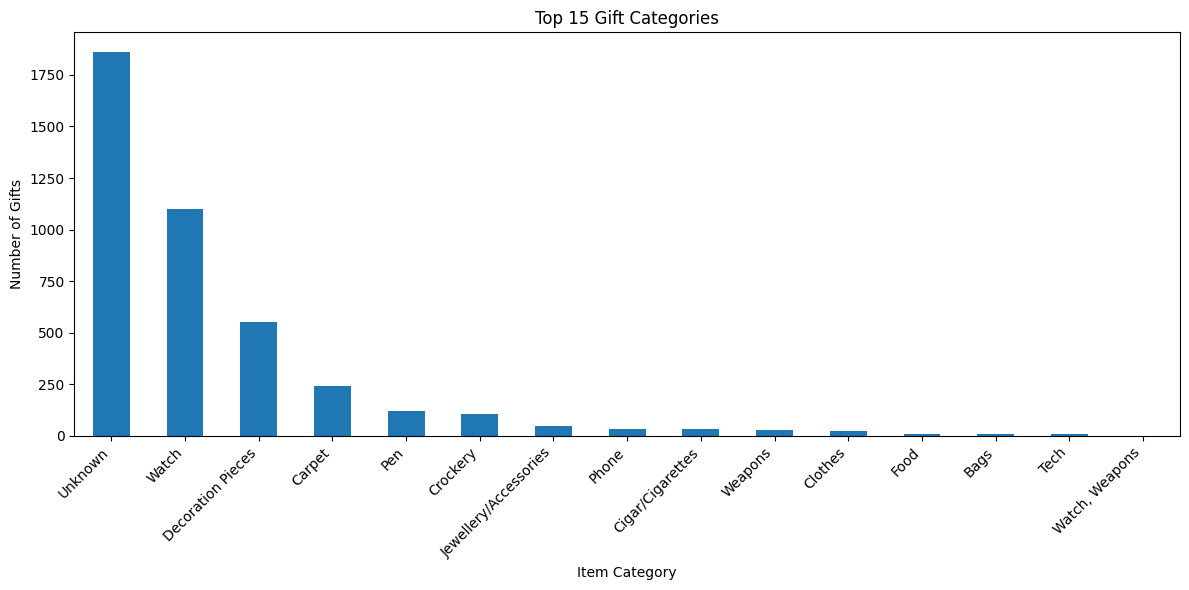

In [69]:
plt.figure(figsize=(12, 6))

df["Item Category"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Gift Categories")
plt.xlabel("Item Category")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.3 Retention Status Analysis

The retention status of gifts is analyzed to determine how many gifts were retained and how many were not retained.

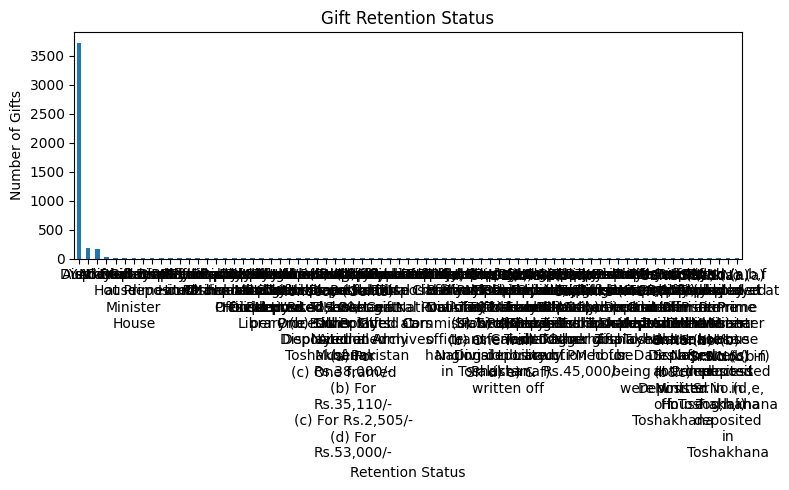

In [70]:
plt.figure(figsize=(8, 5))

df["Retained"].value_counts().plot(kind="bar")

plt.title("Gift Retention Status")
plt.xlabel("Retention Status")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.4 Top Gift Recipients

The frequency of gift records for each recipient is analyzed to identify recipients with the highest number of recorded gifts.

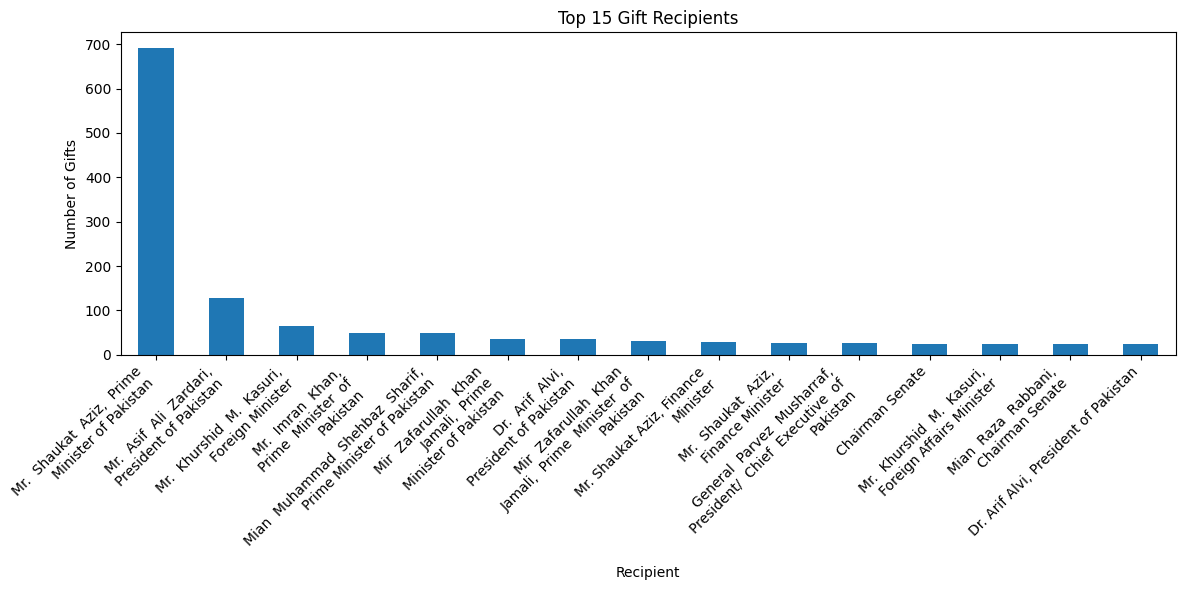

In [71]:
top_recipients = df["Name of Recipient"].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_recipients.plot(kind="bar")

plt.title("Top 15 Gift Recipients")
plt.xlabel("Recipient")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.5 Top Affiliations

The affiliation field is analyzed to identify the most frequently occurring affiliations in the dataset.

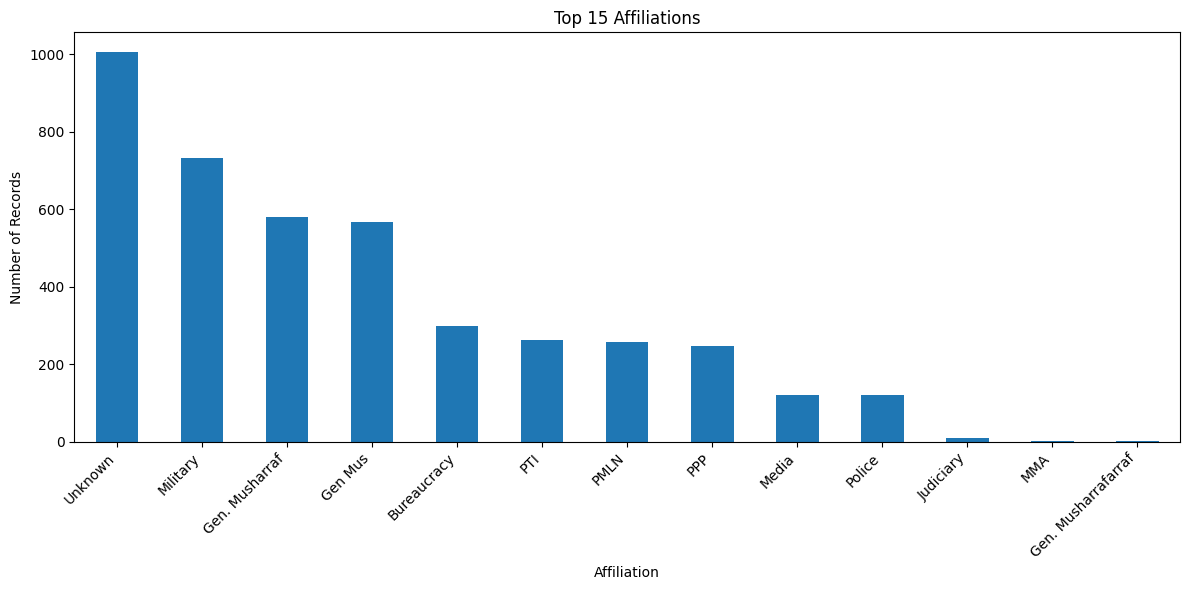

In [72]:
top_affiliations = df["Affiliation"].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_affiliations.plot(kind="bar")

plt.title("Top 15 Affiliations")
plt.xlabel("Affiliation")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Numerical Data Analysis

Numerical variables are analyzed to understand the monetary characteristics of the gifts. The main numerical variables considered are Assessed Value and Retention Cost.

### 11.1 Descriptive Statistics of Monetary Variables

Descriptive statistics are calculated to understand the central tendency and spread of the monetary values.

In [73]:
df[["Assessed Value", "Retention Cost"]].describe()

,Assessed Value,Retention Cost
count,4.197000e+03,4.189000e+03
mean,3.222724e+05,4.869806e+04
std,3.901437e+06,6.196268e+05
min,0.000000e+00,0.000000e+00
25%,1.800000e+03,0.000000e+00
50%,8.000000e+03,0.000000e+00
75%,4.000000e+04,2.269000e+03
max,1.400000e+08,2.017800e+07


### 11.2 Distribution of Assessed Value

The distribution of assessed gift values is visualized using a histogram. This helps identify the overall distribution and potential skewness in gift values.

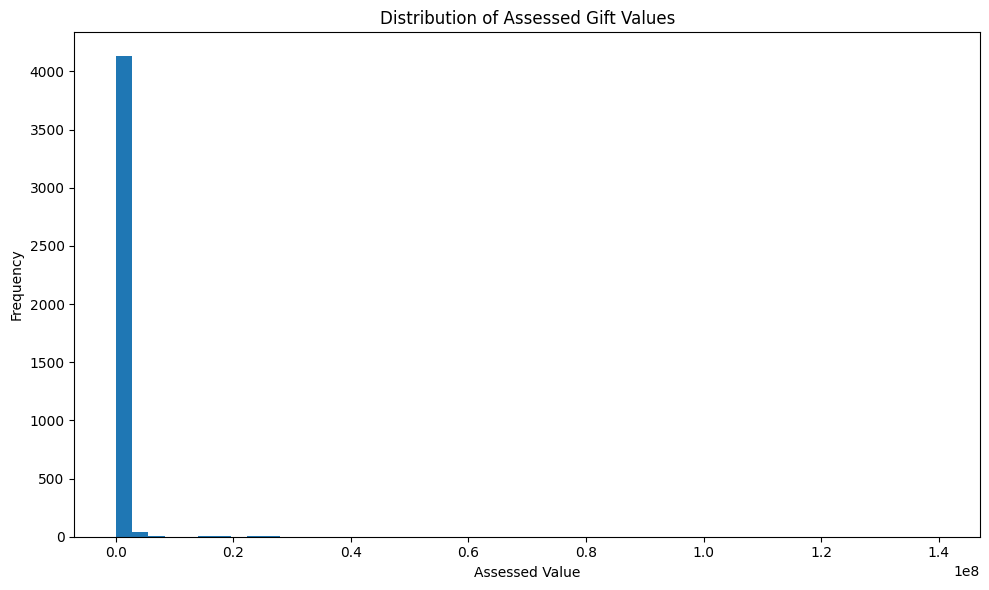

In [74]:
plt.figure(figsize=(10, 6))

plt.hist(df["Assessed Value"].dropna(), bins=50)

plt.title("Distribution of Assessed Gift Values")
plt.xlabel("Assessed Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 11.3 Distribution of Retention Cost

The distribution of retention costs is visualized to understand how much recipients paid to retain gifts.

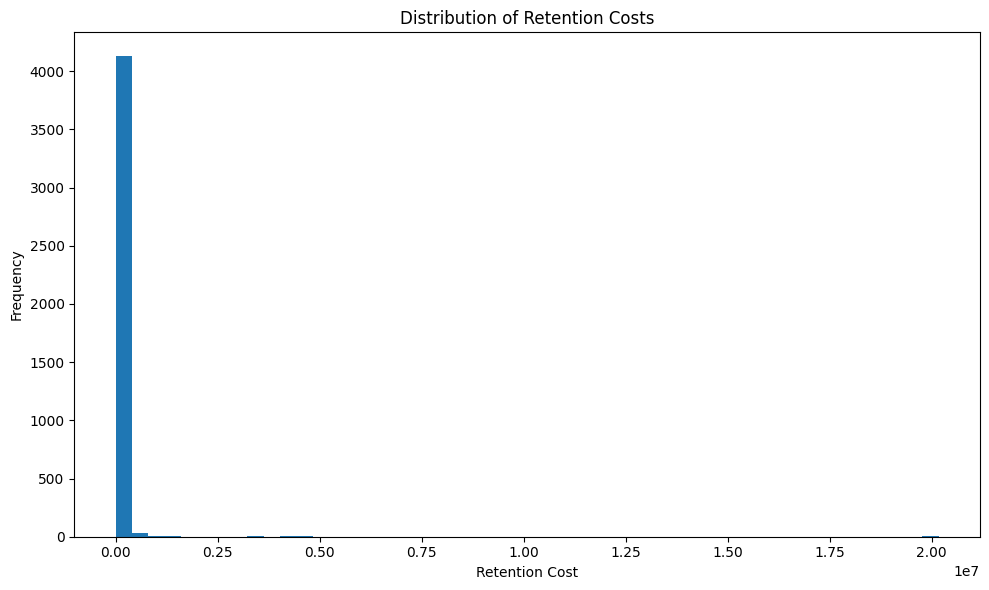

In [75]:
plt.figure(figsize=(10, 6))

plt.hist(df["Retention Cost"].dropna(), bins=50)

plt.title("Distribution of Retention Costs")
plt.xlabel("Retention Cost")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 11.4 Box Plot of Assessed Value

A box plot is used to identify the spread of assessed gift values and detect potential outliers.

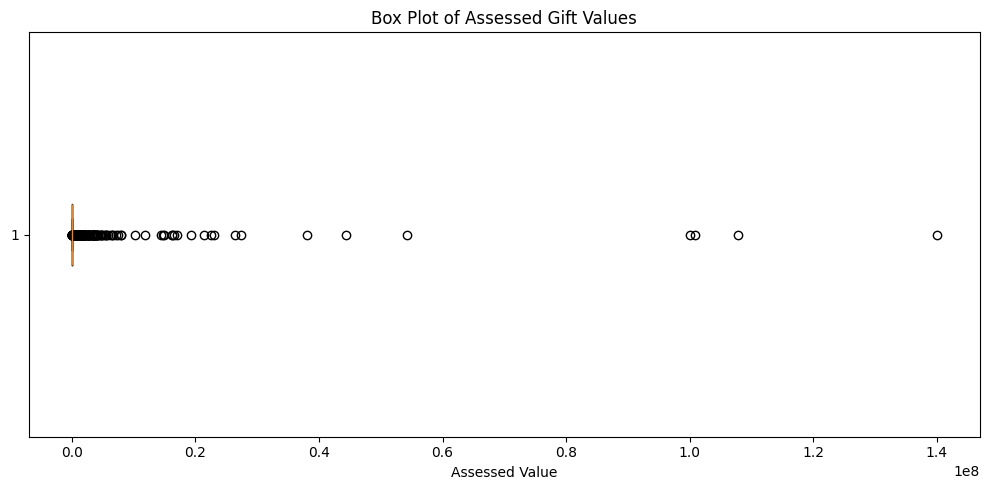

In [76]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["Assessed Value"].dropna(), vert=False)

plt.title("Box Plot of Assessed Gift Values")
plt.xlabel("Assessed Value")
plt.tight_layout()
plt.show()

### 11.5 Box Plot of Retention Cost

A box plot is used to examine the distribution and potential outliers of retention costs.

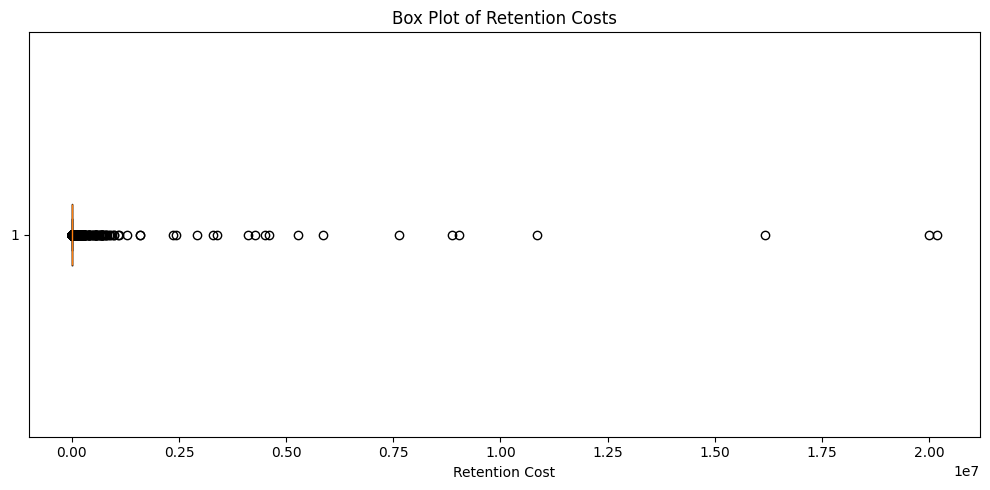

In [77]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["Retention Cost"].dropna(), vert=False)

plt.title("Box Plot of Retention Costs")
plt.xlabel("Retention Cost")
plt.tight_layout()
plt.show()

### 11.6 Highest-Valued Gifts

The records with the highest assessed values are examined to identify the most valuable gifts in the dataset.

In [78]:
top_valuable_gifts = df.sort_values(
    by="Assessed Value",
    ascending=False
).head(10)

top_valuable_gifts[
    ["Name of Recipient", "Detail of Gifts", "Item Category", "Date", "Assessed Value", "Retention Cost"]
]

,Name of Recipient,Detail of Gifts,Item Category,Date,Assessed Value,Retention Cost
4114,"Mian Muhammad Shehbaz Sharif,\nPrime Minist...",One wrist watch Rolex\n(Model\nNo.326259TBR-Sr...,Watch,2022-05-12,140000000.0,0.0
2207,"Mr. Asif Ali Zardari,\nPresident of\nPakistan",a. One BMW 760 Li\n(Security version)\n(mo...,Unknown,2009-01-26,107828705.0,16172806.0
3600,"Prime Minister of\nPakistan, Imran\nKhan",a) (One W/Watch (Graff\nNo.AU750) 18k gold...,Watch,2018-09-24,100920000.0,20178000.0
3463,"Ms. Sameena Shahid,\nwife of Mr. Shahid\nK...","One jewelry set\nincluding one necklace,\na ...",Unknown,2017-10-17,99984000.0,19990800.0
3249,"Begum Prime Minister\nof Pakistan, Wife of M...",(a)One Bracelet.\n(b)One Necklace & Ear\nRing.,Unknown,2016-01-13,54325000.0,10863000.0
3496,"Khawaja Muhammad\nAsif, Foreign Minister",a) One W/Watch\n(Faberge TOF14-\nLimited Ed...,Watch,2017-12-05,44400000.0,8874000.0
3248,"Mr. Muhammad Nawaz\nSharif, Prime Minister\...",(a)One W/ Watch\n(Christopher Claret)\n(b)On...,Watch,2016-01-13,38117859.0,7621572.0
2208,"Mr Asif Ali Zardari,\nPresident of\nPakistan",One BMW 760 Li\nwhite (Security\nversion) ...,Unknown,2009-01-26,27339370.0,4099406.0
3560,"Mr. Shahid Khaqan\nAbbasi, Prime\nMinister o...",a) One W/Watch (Rolex)\n(G018149)\nb) Pair of...,Watch,2018-04-17,26425000.0,5279000.0
3478,"Prime Minister of\nPakistan, Mr. Shahid\nK...",One Box containing\none W/Watch (Rolex\nNo...,Watch,2017-11-28,23000000.0,4594000.0


### 11.7 Correlation Between Monetary Variables

The correlation between Assessed Value and Retention Cost is examined to determine whether there is a relationship between the assessed value of a gift and the cost paid for retaining it.

In [79]:
correlation = df[["Assessed Value", "Retention Cost"]].corr()

correlation

,Assessed Value,Retention Cost
Assessed Value,1.000000,0.786834
Retention Cost,0.786834,1.000000


### 11.8 Correlation Heatmap

A heatmap is used to visualize the correlation between the numerical variables.

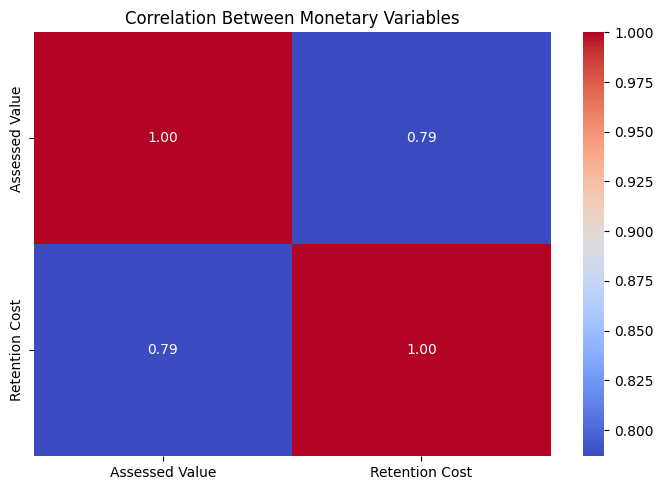

In [80]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Monetary Variables")
plt.tight_layout()
plt.show()

## 12. Time-Based Analysis

Time-based analysis is performed to identify yearly patterns and trends in the Pakistan Toshakhana records. The analysis focuses on the number of recorded gifts and their assessed values over time.

### 12.1 Extracting Year from Date

The year is extracted from the cleaned Date column to enable year-wise analysis.

In [81]:
df["Year"] = df["Date"].dt.year

df["Year"].value_counts().sort_index()

Year
2002.0    252
2003.0    286
2004.0    346
2005.0    470
2006.0    371
2007.0    353
2008.0    114
2009.0    141
2010.0    136
2011.0    291
2012.0    138
2013.0     65
2014.0     89
2015.0    175
2016.0    146
2017.0    113
2018.0    160
2019.0    198
2020.0     79
2021.0    112
2022.0    160
Name: count, dtype: int64

### 12.2 Number of Gifts by Year

The number of recorded gifts for each year is analyzed to identify years with higher or lower numbers of records.

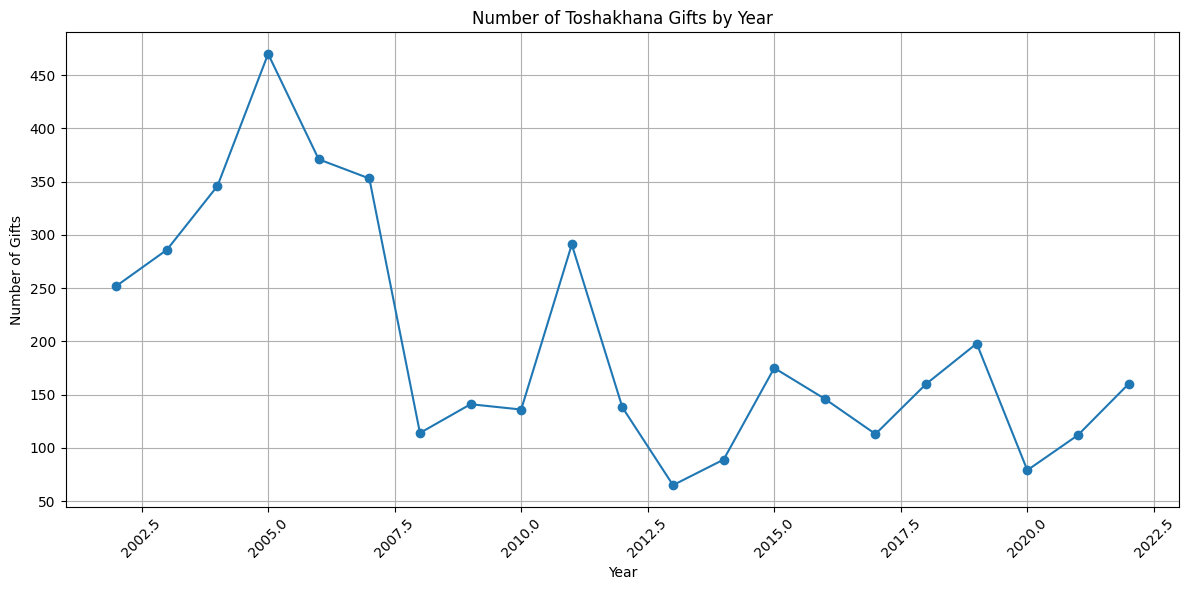

In [82]:
yearly_gifts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(yearly_gifts.index, yearly_gifts.values, marker="o")

plt.title("Number of Toshakhana Gifts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 12.3 Average Assessed Value by Year

The average assessed value of gifts is calculated for each year to examine changes in gift values over time.

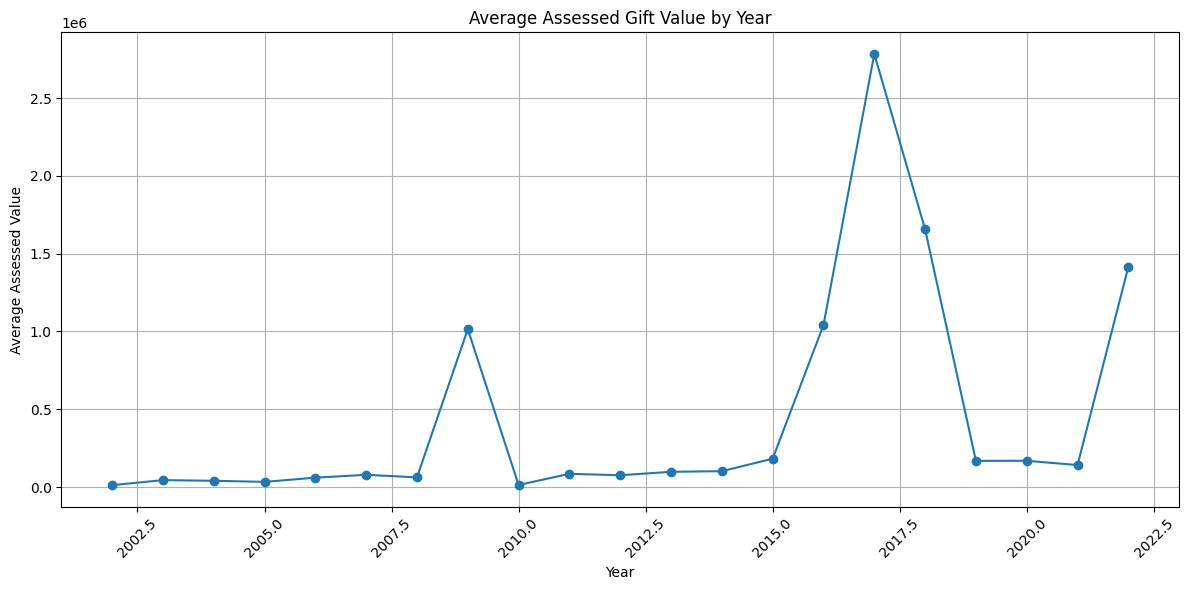

In [83]:
yearly_value = df.groupby("Year")["Assessed Value"].mean()

plt.figure(figsize=(12, 6))

plt.plot(yearly_value.index, yearly_value.values, marker="o")

plt.title("Average Assessed Gift Value by Year")
plt.xlabel("Year")
plt.ylabel("Average Assessed Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 12.4 Total Assessed Value by Year

The total assessed value of recorded gifts is calculated for each year to identify years with the highest overall assessed gift value.

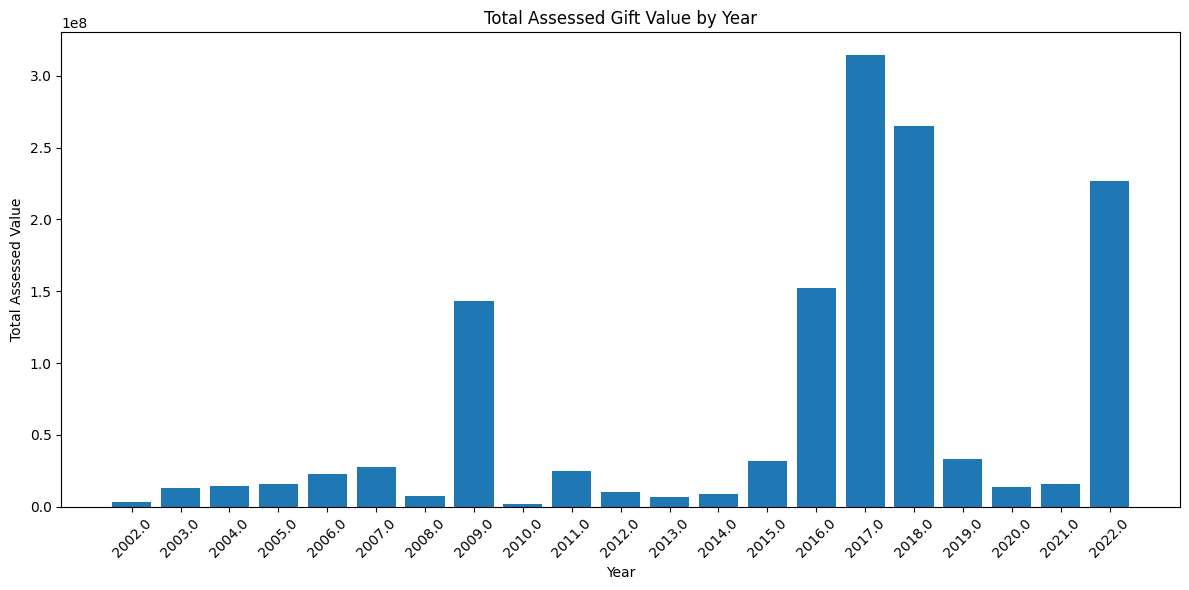

In [84]:
yearly_total_value = df.groupby("Year")["Assessed Value"].sum()

plt.figure(figsize=(12, 6))

plt.bar(yearly_total_value.index.astype(str), yearly_total_value.values)

plt.title("Total Assessed Gift Value by Year")
plt.xlabel("Year")
plt.ylabel("Total Assessed Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 12.5 Year with the Highest Number of Gifts

The year containing the highest number of recorded gifts is identified.

In [85]:
year_with_most_gifts = yearly_gifts.idxmax()
number_of_gifts = yearly_gifts.max()

print("Year with the highest number of gifts:", year_with_most_gifts)
print("Number of gifts:", number_of_gifts)

Year with the highest number of gifts: 2005.0
Number of gifts: 470


### 12.6 Year with the Highest Total Assessed Value

The year with the highest total assessed value of recorded gifts is identified.

In [86]:
year_highest_value = yearly_total_value.idxmax()
highest_total_value = yearly_total_value.max()

print("Year with the highest total assessed value:", year_highest_value)
print("Total assessed value:", highest_total_value)

Year with the highest total assessed value: 2017.0
Total assessed value: 314552288.0


### 12.7 Yearly Summary

A summary table is created to compare the number of gifts, average assessed value, and total assessed value for each year.

In [87]:
yearly_summary = pd.DataFrame({
    "Number of Gifts": yearly_gifts,
    "Average Assessed Value": yearly_value,
    "Total Assessed Value": yearly_total_value
})

yearly_summary

,Number of Gifts,Average Assessed Value,Total Assessed Value
Year,,,
2002.0,252,1.252978e+04,3157505.0
2003.0,286,4.461760e+04,12760634.0
2004.0,346,4.053175e+04,14023987.0
2005.0,470,3.361259e+04,15797917.0
2006.0,371,6.064600e+04,22499667.0
2007.0,353,7.885224e+04,27834840.0
2008.0,114,6.265017e+04,7142119.0
2009.0,141,1.015049e+06,143121895.0
2010.0,136,1.359632e+04,1849100.0


## 13. Recipient Analysis

Recipient analysis is performed to understand the distribution of Toshakhana gift records among different recipients. The analysis identifies recipients with the highest number of recorded gifts and compares their assessed gift values.

### 13.1 Number of Records by Recipient

The number of Toshakhana records associated with each recipient is calculated to identify the most frequently occurring recipients.

In [88]:
recipient_counts = df["Name of Recipient"].value_counts()

recipient_counts.head(20)

Name of Recipient
Mr.  Shaukat  Aziz,  Prime\nMinister of Pakistan                           692
Mr.  Asif  Ali  Zardari,\nPresident of Pakistan                            128
Mr.  Khurshid  M.  Kasuri,\nForeign Minister                                65
Mr.  Imran  Khan,\nPrime  Minister  of\nPakistan                            49
Mian  Muhammad  Shehbaz  Sharif,\nPrime Minister of Pakistan                48
Mir  Zafarullah  Khan\nJamali,  Prime\nMinister of Pakistan                 36
Dr.  Arif  Alvi,\nPresident of Pakistan                                     35
Mir  Zafarullah  Khan\nJamali,  Prime  Minister  of\nPakistan               31
Mr. Shaukat Aziz, Finance\nMinister                                         29
Mr.  Shaukat  Aziz,\nFinance Minister                                       27
General  Parvez  Musharraf,\nPresident/  Chief  Executive  of\nPakistan     26
Chairman Senate                                                             25
Mr.  Khurshid  M.  Kasuri,\nForeig

### 13.2 Top 10 Recipients by Number of Gifts

The top 10 recipients with the highest number of recorded gifts are visualized using a bar chart.

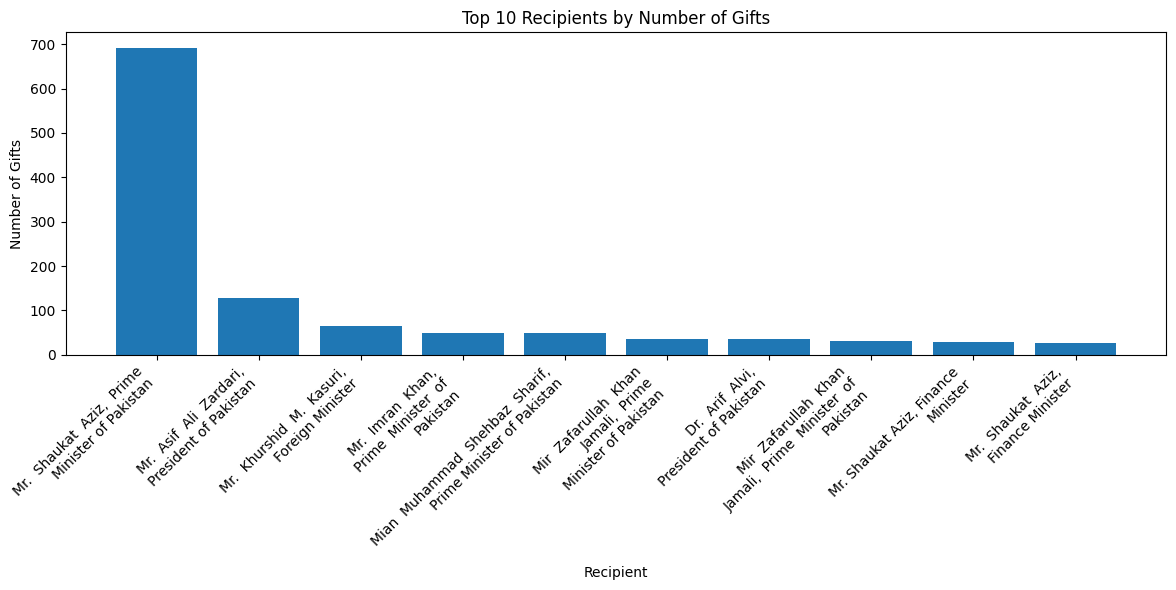

In [89]:
top_10_recipients = recipient_counts.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_recipients.index,
    top_10_recipients.values
)

plt.title("Top 10 Recipients by Number of Gifts")
plt.xlabel("Recipient")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 13.3 Total Assessed Value by Recipient

The total assessed value of gifts is calculated for each recipient to identify recipients associated with higher overall assessed gift values.

In [90]:
recipient_value = (
    df.groupby("Name of Recipient")["Assessed Value"]
    .sum()
    .sort_values(ascending=False)
)

recipient_value.head(10)

Name of Recipient
Mian  Muhammad  Shehbaz  Sharif,\nPrime Minister of Pakistan                      159456850.0
Mr.  Asif  Ali  Zardari,\nPresident  of\nPakistan                                 108315205.0
Prime  Minister  of\nPakistan,  Imran\nKhan                                       105760000.0
Ms. Sameena  Shahid,\nwife  of  Mr.  Shahid\nKhaqan  Abbasi,  Prime\nMinister,     99984000.0
Mr. Muhammad  Nawaz\nSharif,  Prime  Minister\nof Pakistan                         61183779.0
Khawaja  Muhammad\nAsif, Foreign Minister                                          56218788.0
Begum  Prime  Minister\nof Pakistan, Wife of Mr.\nMuhammad  Nawaz\nSharif          54325000.0
Mr.  Shaukat  Aziz,  Prime\nMinister of Pakistan                                   29006997.0
Mr. Shahid Khaqan\nAbbasi,  Prime\nMinister  of\nPakistan                          27470000.0
Mr  Asif  Ali  Zardari,\nPresident  of\nPakistan                                   27339370.0
Name: Assessed Value, dtype: float64

### 13.4 Top 10 Recipients by Total Assessed Value

The top 10 recipients by total assessed gift value are visualized.

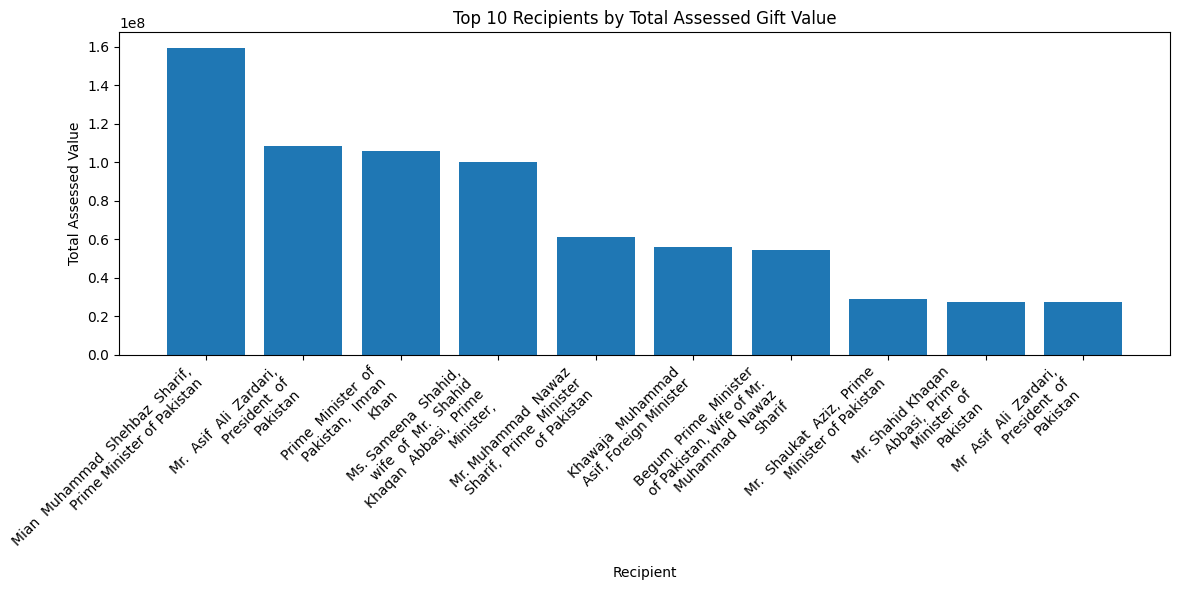

In [91]:
top_10_value_recipients = recipient_value.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_value_recipients.index,
    top_10_value_recipients.values
)

plt.title("Top 10 Recipients by Total Assessed Gift Value")
plt.xlabel("Recipient")
plt.ylabel("Total Assessed Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 13.5 Average Gift Value by Recipient

The average assessed gift value is calculated for recipients with recorded gift values. This helps compare the typical assessed value of gifts associated with different recipients.

In [92]:
recipient_avg_value = (
    df.groupby("Name of Recipient")["Assessed Value"]
    .mean()
    .sort_values(ascending=False)
)

recipient_avg_value.head(10)

Name of Recipient
Ms. Sameena  Shahid,\nwife  of  Mr.  Shahid\nKhaqan  Abbasi,  Prime\nMinister,    99984000.0
Begum  Prime  Minister\nof Pakistan, Wife of Mr.\nMuhammad  Nawaz\nSharif         54325000.0
Khawaja  Muhammad\nAsif, Foreign Minister                                         28109394.0
Mr  Asif  Ali  Zardari,\nPresident  of\nPakistan                                  27339370.0
Prime  Minister  of\nPakistan,\nMr.  Shahid  Khaqan\nAbbasi                       22550000.0
Mr.  Abdullah  Khaqan\nAbbasi.                                                    21346000.0
Prime  Minister  of\nPakistan,  Imran\nKhan                                       21152000.0
Mr.  Nadir  Khaqan\nAbbasi,  son  of\nPrime Minister                              17000000.0
First lady, Wife of the\nPresident  of  Pakistan,\nMr.  Mamnoon\nHussain          16604188.0
First  Lady,\nSameena Alvi                                                        14827860.0
Name: Assessed Value, dtype: float64

### 13.6 Recipient Summary

A summary table is created containing the number of gifts, total assessed value, and average assessed value for each recipient.

In [49]:
recipient_summary = df.groupby("Name of Recipient").agg(
    Number_of_Gifts=("Name of Recipient", "size"),
    Total_Assessed_Value=("Assessed Value", "sum"),
    Average_Assessed_Value=("Assessed Value", "mean")
).sort_values(
    "Number_of_Gifts",
    ascending=False
)

recipient_summary.head(20)

,Number_of_Gifts,Total_Assessed_Value,Average_Assessed_Value
Name of Recipient,,,
"Mr. Shaukat Aziz, Prime\nMinister of Pakistan",692,29006997.0,4.191763e+04
"Mr. Asif Ali Zardari,\nPresident of Pakistan",128,8288155.0,6.475121e+04
"Mr. Khurshid M. Kasuri,\nForeign Minister",65,944890.0,1.453677e+04
"Mr. Imran Khan,\nPrime Minister of\nPakistan",49,5415500.0,1.105204e+05
"Mian Muhammad Shehbaz Sharif,\nPrime Minister of Pakistan",48,159456850.0,3.322018e+06
"Mir Zafarullah Khan\nJamali, Prime\nMinister of Pakistan",36,1435935.0,3.988708e+04
"Dr. Arif Alvi,\nPresident of Pakistan",35,1596900.0,4.562571e+04
"Mir Zafarullah Khan\nJamali, Prime Minister of\nPakistan",31,240075.0,7.744355e+03
"Mr. Shaukat Aziz, Finance\nMinister",29,414663.0,1.429872e+04


## 14. Gift Category Analysis

Gift categories are analyzed to identify the most common categories and compare their assessed values.

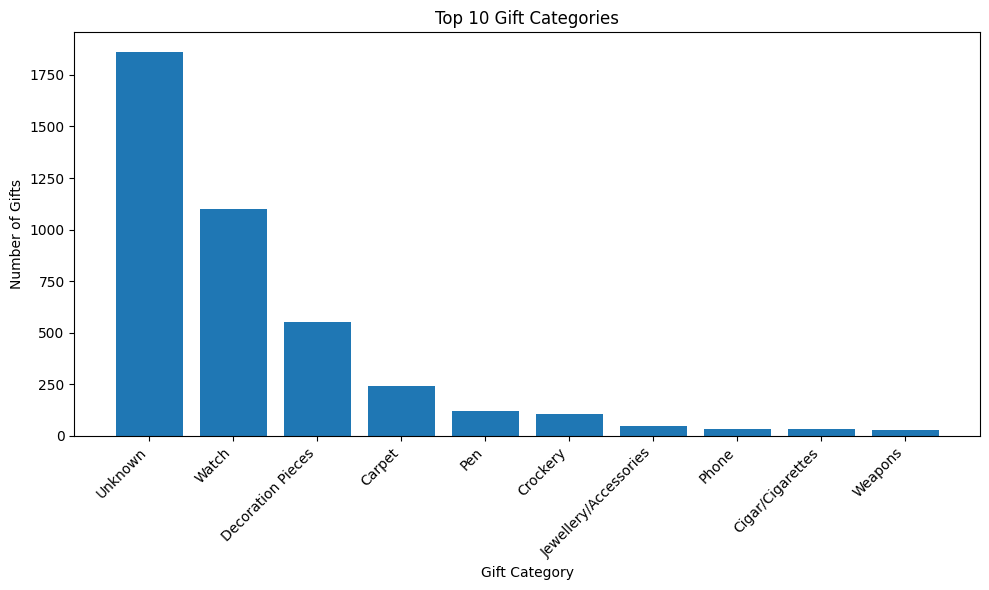

In [47]:
# Top 10 gift categories by number of records

category_counts = df["Item Category"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values)

plt.title("Top 10 Gift Categories")
plt.xlabel("Gift Category")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 14.1 Assessed Value by Gift Category

The total assessed value is calculated for each gift category to identify categories associated with higher overall values.

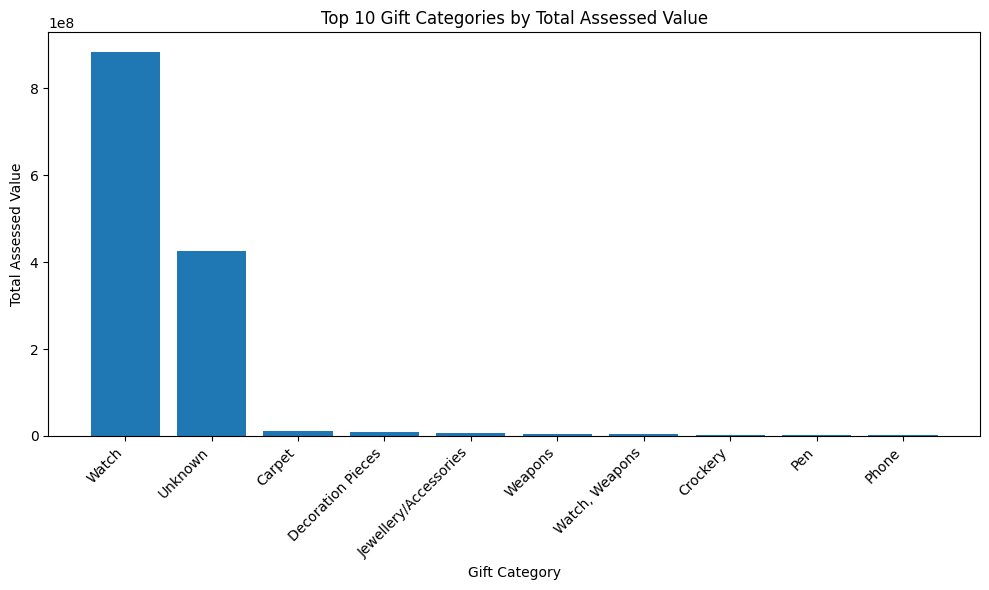

In [48]:
category_value = (
    df.groupby("Item Category")["Assessed Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(category_value.index, category_value.values)

plt.title("Top 10 Gift Categories by Total Assessed Value")
plt.xlabel("Gift Category")
plt.ylabel("Total Assessed Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Outlier Analysis

Outliers are identified in the monetary variables using the Interquartile Range (IQR) method. This helps identify unusually high or low assessed gift values.

In [93]:
Q1 = df["Assessed Value"].quantile(0.25)
Q3 = df["Assessed Value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Assessed Value"] < lower_bound) |
    (df["Assessed Value"] > upper_bound)
]

print("Number of Assessed Value outliers:", len(outliers))

Number of Assessed Value outliers: 545


### 15.1 Highest Assessed Value Outliers

The highest assessed-value records are displayed to examine the extreme observations in the dataset.

In [94]:
outliers.sort_values(
    "Assessed Value",
    ascending=False
)[
    ["Name of Recipient", "Detail of Gifts", "Item Category", "Assessed Value"]
].head(10)

,Name of Recipient,Detail of Gifts,Item Category,Assessed Value
4114,"Mian Muhammad Shehbaz Sharif,\nPrime Minist...",One wrist watch Rolex\n(Model\nNo.326259TBR-Sr...,Watch,140000000.0
2207,"Mr. Asif Ali Zardari,\nPresident of\nPakistan",a. One BMW 760 Li\n(Security version)\n(mo...,Unknown,107828705.0
3600,"Prime Minister of\nPakistan, Imran\nKhan",a) (One W/Watch (Graff\nNo.AU750) 18k gold...,Watch,100920000.0
3463,"Ms. Sameena Shahid,\nwife of Mr. Shahid\nK...","One jewelry set\nincluding one necklace,\na ...",Unknown,99984000.0
3249,"Begum Prime Minister\nof Pakistan, Wife of M...",(a)One Bracelet.\n(b)One Necklace & Ear\nRing.,Unknown,54325000.0
3496,"Khawaja Muhammad\nAsif, Foreign Minister",a) One W/Watch\n(Faberge TOF14-\nLimited Ed...,Watch,44400000.0
3248,"Mr. Muhammad Nawaz\nSharif, Prime Minister\...",(a)One W/ Watch\n(Christopher Claret)\n(b)On...,Watch,38117859.0
2208,"Mr Asif Ali Zardari,\nPresident of\nPakistan",One BMW 760 Li\nwhite (Security\nversion) ...,Unknown,27339370.0
3560,"Mr. Shahid Khaqan\nAbbasi, Prime\nMinister o...",a) One W/Watch (Rolex)\n(G018149)\nb) Pair of...,Watch,26425000.0
3478,"Prime Minister of\nPakistan, Mr. Shahid\nK...",One Box containing\none W/Watch (Rolex\nNo...,Watch,23000000.0


## 16. Final Dataset Summary

A final summary is generated to review the cleaned dataset and its main characteristics before concluding the EDA.

In [95]:
print("Final Dataset Shape:", df.shape)

print("\nNumber of Unique Recipients:",
      df["Name of Recipient"].nunique())

print("Number of Gift Categories:",
      df["Item Category"].nunique())

print("Date Range:",
      df["Date"].min(),
      "to",
      df["Date"].max())

print("Total Assessed Value:",
      df["Assessed Value"].sum())

print("Total Retention Cost:",
      df["Retention Cost"].sum())

Final Dataset Shape: (4198, 10)

Number of Unique Recipients: 2047
Number of Gift Categories: 23
Date Range: 2002-01-08 00:00:00 to 2022-10-24 00:00:00
Total Assessed Value: 1352577261.0
Total Retention Cost: 203996160.0


## 17. Key Insights

The following key insights are derived from the exploratory analysis:

1. The dataset contains thousands of Toshakhana gift records covering multiple years.

2. Several records contain missing information, particularly in Item Category and Affiliation. These values were retained and labeled as "Unknown" instead of removing the records.

3. Gift records are not evenly distributed across recipients or categories. A relatively small number of recipients and categories account for a significant portion of the records.

4. Assessed gift values show variation and contain potential high-value outliers.

5. Retention Cost provides additional information about the financial cost associated with retained gifts.

6. Year-wise analysis reveals changes in the number and value of recorded gifts over time.

7. Visualization helps identify distributions, trends, differences between categories, and unusual observations more clearly.

8. The analysis provides descriptive insights into the dataset but does not establish causal relationships or verify the authenticity of individual records.

## 18. Conclusion

The Pakistan Toshakhana Exploratory Data Analysis project successfully examined the structure, quality, distributions, trends, relationships, and outliers within the dataset.

The dataset was cleaned by handling duplicate records, missing categorical values, date formats, and numerical data types. Different EDA techniques were then applied to analyze recipients, gift categories, monetary values, yearly trends, and outliers.

The visualizations and statistical analysis provide a clearer understanding of the patterns present in the Pakistan Toshakhana dataset. The project demonstrates the practical use of Python, Pandas, NumPy, Matplotlib, Seaborn, and statistical techniques for analyzing a real-world dataset.

Overall, the project fulfills the main objectives of exploratory data analysis and provides a reproducible foundation for further analysis.

In [96]:
# Dataset columns
df.columns.tolist()

['Detail of Gifts',
 'Item Category',
 'Name of Recipient',
 'Affiliation',
 'Date',
 'Assessed Value',
 'Retention Cost',
 'Retained',
 'Remarks',
 'Year']

In [97]:
# Target column ke unique values aur data type check
df.dtypes

Detail of Gifts              object
Item Category                object
Name of Recipient            object
Affiliation                  object
Date                 datetime64[ns]
Assessed Value              float64
Retention Cost              float64
Retained                     object
Remarks                      object
Year                        float64
dtype: object

In [98]:
# Target variable
y = df['Assessed Value']

# Input features
X = df.drop('Assessed Value', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4198, 9)
y shape: (4198,)


In [99]:
# Remove unnecessary columns
X = X.drop(['Detail of Gifts', 'Remarks', 'Date'], axis=1)

X.head()

,Item Category,Name of Recipient,Affiliation,Retention Cost,Retained,Year
0,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharrafarraf,0.0,Yes,2002.0
1,Pen,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharraf,0.0,Yes,2002.0
2,Decoration Pieces,"Mr. Shaukat Aziz, Minister for Finance",Gen. Musharraf,0.0,Yes,2002.0
3,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nAf...",Gen. Musharraf,0.0,Yes,2002.0
4,Decoration Pieces,"Mr. Abdul Sattar, Minister for Foreign\nA...",Gen. Musharraf,0.0,Yes,2002.0


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

In [103]:
# Remove rows where target value is missing
mask = y.notna()

X = X[mask]
y = y[mask]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4197, 6)
y shape: (4197,)


In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3357, 6)
Testing data: (840, 6)


In [105]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [106]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[8.35050000e+02 2.63302809e+03 2.34097080e+06 1.59455000e+04
 1.60903996e+05 5.00300000e+04 3.04381293e+03 6.32272222e+03
 1.18267280e+05 4.90500000e+04]


In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 158563.0964606639
RMSE: 1295044.064329849
R² Score: 0.7526352141147232


In [108]:
results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [mae, rmse, r2]
})

results

,Metric,Value
0,MAE,1.585631e+05
1,RMSE,1.295044e+06
2,R² Score,7.526352e-01


In [109]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

MAE: 179633.97379855503
RMSE: 1467259.4001669302
R² Score: 0.6824715930348491


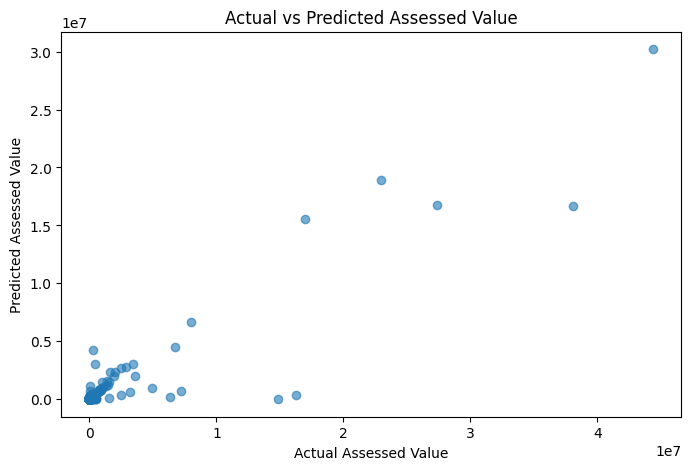

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Assessed Value")
plt.ylabel("Predicted Assessed Value")
plt.title("Actual vs Predicted Assessed Value")

plt.show()

In [111]:
import joblib

# Save the best model
joblib.dump(model, 'toshakhana_random_forest_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [112]:
import os

print(os.path.exists('toshakhana_random_forest_model.pkl'))

True


In [116]:
import os

file_path = os.path.abspath('toshakhana_random_forest_model.pkl')

print(file_path)
print(os.path.exists(file_path))

/kaggle/working/toshakhana_random_forest_model.pkl
True
